In [0]:
# Install kagglehub package for dataset downloading
%pip install kagglehub

import kagglehub
import pandas as pd
import os

# Auto-download the stroke dataset from Kaggle (caches locally)
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)

# Locate the CSV file in downloaded directory
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

# Read the first CSV file found
if csv_files:
    csv_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_path)  # Load into pandas dataframe
    
    # Display basic info about loaded dataset
    print(f"\nLoaded dataset: {csv_files[0]}")
    print(f"Shape: {df.shape}")
    display(df.head(10))  # Show first 10 records

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Path to dataset files: /home/spark-9fe86373-fcf9-4675-aa52-21/.cache/kagglehub/datasets/fedesoriano/stroke-prediction-dataset/versions/1

Loaded dataset: healthcare-dataset-stroke-data.csv
Shape: (5110, 12)


id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,null,never smoked,1
31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
27419,Female,59.0,0,0,Yes,Private,Rural,76.15,null,Unknown,1
60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [0]:
# Import core libraries for data analysis and visualization
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set consistent visual style for all plots
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42  # For reproducible results

In [0]:
# Quick sanity check on the loaded data
print(f'Shape: {df.shape}')
df.head()  # Preview first 5 rows

Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [0]:
# Check data types to verify correct loading (numeric vs string)
print(df.dtypes)

# Count missing values per column
# Expect: BMI has 201 missing (~4% of data)
print('\nMissing values:')
print(df.isnull().sum())

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

Missing values:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


stroke
0    4861
1     249
Name: count, dtype: int64

Positive class rate: 4.87%


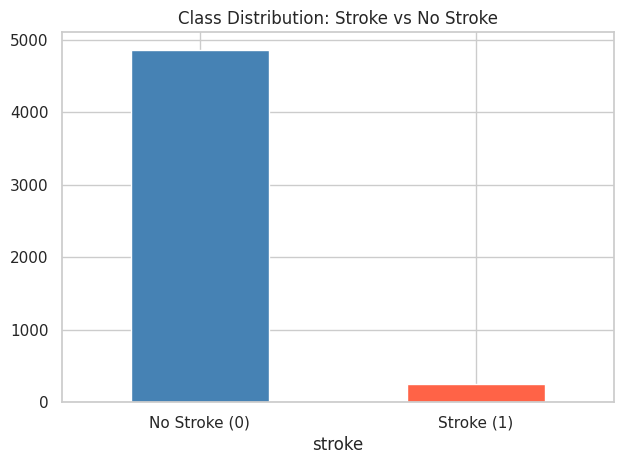

In [0]:
# Check class balance - critical for model evaluation
print(df['stroke'].value_counts())
print(f"\nPositive class rate: {df['stroke'].mean():.2%}")

# Create bar chart to visualize class imbalance
fig, ax = plt.subplots()
df['stroke'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])

# Label the chart clearly
ax.set_title('Class Distribution: Stroke vs No Stroke')
ax.set_xticklabels(['No Stroke (0)', 'Stroke (1)'], rotation=0)

# Format and display
plt.tight_layout()
plt.show()

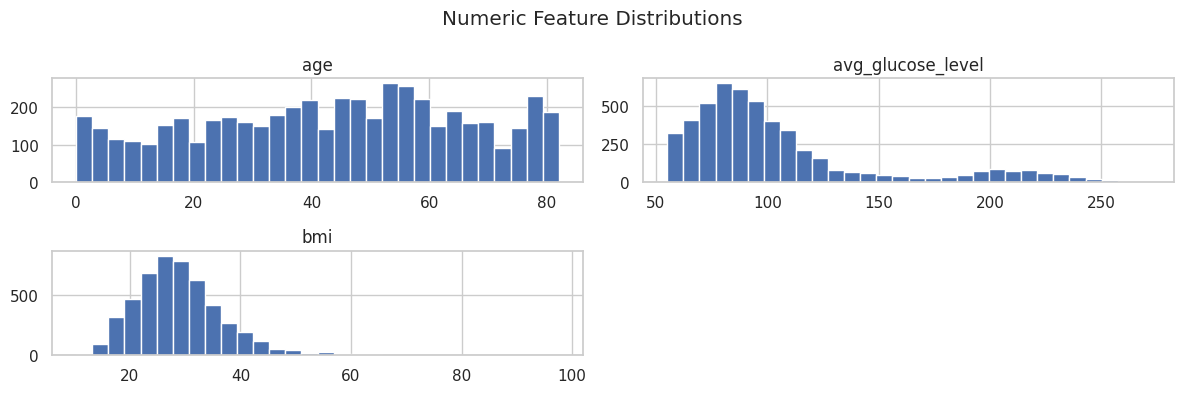

In [0]:
# Define numeric columns to analyze
numeric_cols = ['age', 'avg_glucose_level', 'bmi']

# Create histograms to see distribution shapes
df[numeric_cols].hist(bins=30, figsize=(12, 4))

# Add title and format
plt.suptitle('Numeric Feature Distributions')
plt.tight_layout()
plt.show()

In [0]:
# List all categorical columns to examine
cat_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married',
            'work_type', 'Residence_type', 'smoking_status']

# Print frequency counts for each categorical feature
for col in cat_cols:
    print(df[col].value_counts(), '\n')

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64 

hypertension
0    4612
1     498
Name: count, dtype: int64 

heart_disease
0    4834
1     276
Name: count, dtype: int64 

ever_married
Yes    3353
No     1757
Name: count, dtype: int64 

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64 

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64 

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64 



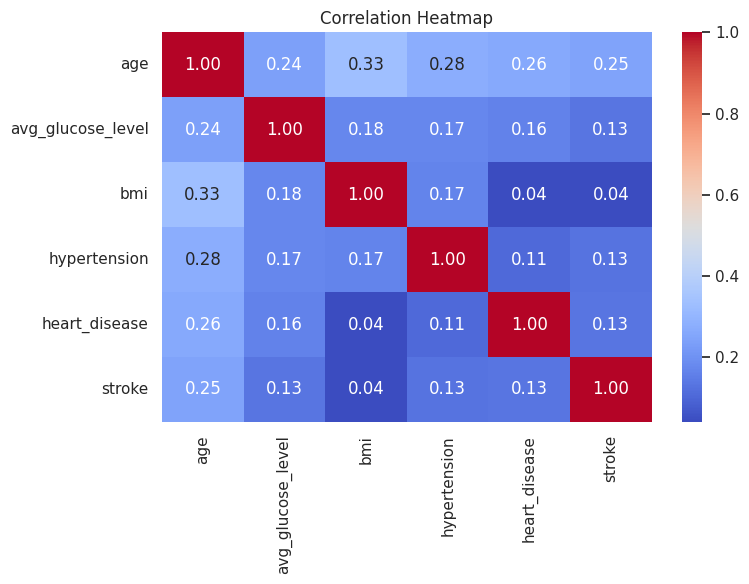

In [0]:
# Create correlation matrix for numeric features and binary indicators
fig, ax = plt.subplots(figsize=(8, 6))

# Compute correlations and display as heatmap
# annot=True shows correlation values, coolwarm uses red/blue color scale
sns.heatmap(df[numeric_cols + ['hypertension', 'heart_disease', 'stroke']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', ax=ax)

ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [0]:
# Start with a copy to preserve original data
df_clean = df.copy()

# Remove ID column (not a predictor, just an identifier)
df_clean.drop(columns=['id'], inplace=True)

# Check for rare category in gender
print(f"Records with gender='Other': {(df_clean['gender'] == 'Other').sum()}")

# Remove the single 'Other' record (too rare to be meaningful)
df_clean = df_clean[df_clean['gender'].isin(['Male', 'Female'])].copy()

print(f"Shape after removing rare category: {df_clean.shape}")

# Handle missing BMI values
# Strategy: impute with median (robust to outliers)
bmi_median = df_clean['bmi'].median()
df_clean['bmi'] = df_clean['bmi'].fillna(bmi_median)
print(f'BMI missing after imputation: {df_clean["bmi"].isnull().sum()}')

# Keep 'Unknown' smoking status as its own category (has 1544 records)
print(df_clean['smoking_status'].value_counts())

# Final verification - should be zero missing values
print("\nFinal missing values:")
print(df_clean.isnull().sum())

Records with gender='Other': 1
Shape after removing rare category: (5109, 11)
BMI missing after imputation: 0
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     884
smokes              789
Name: count, dtype: int64

Final missing values:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [0]:
# One-hot encode categorical variables
# drop_first=True removes one category per variable to avoid multicollinearity
df_encoded = pd.get_dummies(df_clean,
                             columns=['gender', 'ever_married', 'work_type',
                                      'Residence_type', 'smoking_status'],
                             drop_first=True)

# Check the new shape (should have more columns now)
print(f'Shape after encoding: {df_encoded.shape}')

# Preview the encoded dataframe
df_encoded.head()

Shape after encoding: (5109, 16)


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,True,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.1,1,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,1,True,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,1,False,True,False,False,True,False,False,False,True,False


In [0]:
# Dataset now clean and ready for modeling
print(f'Final processed shape: {df_encoded.shape}')
print(f'Features: {df_encoded.shape[1] - 1}')  # Subtract 1 for target column
print(f'Target variable: stroke')
print(f'\nProcessed dataframe stored as: df_encoded')
df_encoded.head()

Final processed shape: (5109, 16)
Features: 15
Target variable: stroke

Processed dataframe stored as: df_encoded


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,True,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.1,1,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,1,True,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,1,False,True,False,False,True,False,False,False,True,False


In [0]:
# Import scikit-learn modules for modeling
from sklearn.model_selection import train_test_split  # For splitting data
from sklearn.linear_model import LogisticRegression  # The classifier
from sklearn.metrics import (classification_report,  # Precision/recall/F1
                              confusion_matrix,  # True/false positives/negatives
                              roc_auc_score,  # Area under ROC curve
                              RocCurveDisplay)  # ROC plotting utility
from sklearn.preprocessing import StandardScaler  # Feature scaling

In [0]:
# Split features (X) from target (y)
X = df_encoded.drop(columns=['stroke'])  # All columns except stroke
y = df_encoded['stroke']  # Binary target: 0 = no stroke, 1 = stroke

# Stratified 80/20 split preserves class distribution in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train positive rate: {y_train.mean():.2%}')
print(f'Test  positive rate: {y_test.mean():.2%}')

# Standardize features (mean=0, std=1) for better convergence
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # Fit on train only
X_test_sc  = scaler.transform(X_test)  # Apply same scaling to test

Train: (4087, 15), Test: (1022, 15)
Train positive rate: 4.87%
Test  positive rate: 4.89%


In [0]:
def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    """Train model and compute evaluation metrics"""
    # Train the model
    model.fit(X_tr, y_tr)
    
    # Get predictions on test set
    y_pred = model.predict(X_te)  # Hard class predictions (0 or 1)
    y_prob = model.predict_proba(X_te)[:, 1]  # Probability scores for positive class
    
    # Calculate ROC-AUC score
    auc = roc_auc_score(y_te, y_prob)
    
    # Generate classification report (precision, recall, F1 per class)
    report = classification_report(y_te, y_pred, output_dict=True)
    
    # Print results to console
    print(f'\n--- {name} ---')
    print(classification_report(y_te, y_pred))
    print(f'ROC-AUC: {auc:.4f}')
    
    # Return metrics dictionary for comparison
    return {
        'model': name,
        'precision_stroke': report['1']['precision'],  # Focus on stroke class (positive)
        'recall_stroke':    report['1']['recall'],  # Most important: catch actual strokes
        'f1_stroke':        report['1']['f1-score'],  # Harmonic mean of precision/recall
        'roc_auc':          auc,  # Overall discrimination ability
        'accuracy':         report['accuracy'],  # Overall correctness
    }

# Initialize list to store results from all models
results = []

In [0]:
# Plain logistic regression with no regularization (default L2 with high C)
lr_base = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

# Train and evaluate, storing results
results.append(evaluate('LR Baseline', lr_base, X_train_sc, X_test_sc, y_train, y_test))


--- LR Baseline ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022

ROC-AUC: 0.8394


In [0]:
# L1 regularization (Lasso) for feature selection
# C=0.1 means strong regularization (inverse of lambda)
# solver='liblinear' required for L1 penalty
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.1,
                            max_iter=1000, random_state=RANDOM_STATE)

# Train and evaluate
results.append(evaluate('LR L1 (C=0.1)', lr_l1, X_train_sc, X_test_sc, y_train, y_test))


--- LR L1 (C=0.1) ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

ROC-AUC: 0.8392


/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/databricks/python/lib/py

In [0]:
# L2 regularization (Ridge) for weight smoothing
# Shrinks coefficients but doesn't zero them out
# C=0.1 means strong regularization (C = 1/lambda)
lr_l2 = LogisticRegression(penalty='l2', C=0.1,
                            max_iter=1000, random_state=RANDOM_STATE)

# Train and evaluate
results.append(evaluate('LR L2 (C=0.1)', lr_l2, X_train_sc, X_test_sc, y_train, y_test))


--- LR L2 (C=0.1) ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022

ROC-AUC: 0.8386


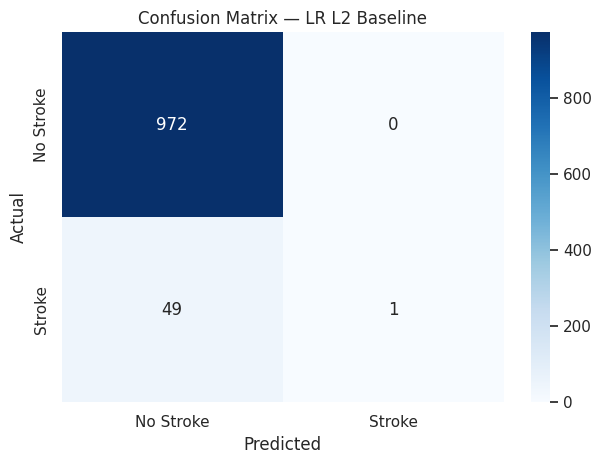

In [0]:
# Select best performing model for visualization
best = lr_l2  # L2 regularization typically performs well

# Generate confusion matrix on test set
cm = confusion_matrix(y_test, best.predict(X_test_sc))

# Create heatmap visualization
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Stroke', 'Stroke'],  # Column labels
            yticklabels=['No Stroke', 'Stroke'])  # Row labels

# Add title and axis labels
ax.set_title('Confusion Matrix — LR L2 Baseline')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

# Format and display
plt.tight_layout()
plt.show()

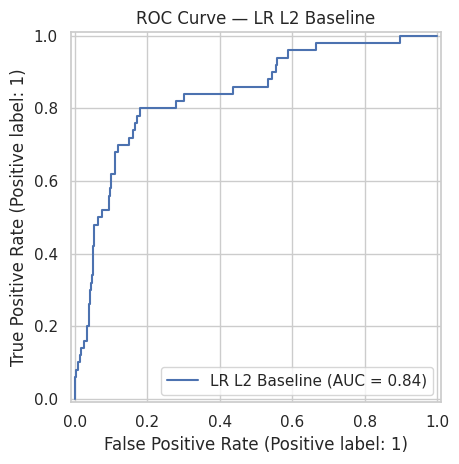

In [0]:
# Plot ROC curve to visualize model's ability to distinguish classes
# Shows tradeoff between true positive rate and false positive rate
fig, ax = plt.subplots()

# Generate ROC curve from best model
RocCurveDisplay.from_estimator(best, X_test_sc, y_test, ax=ax, name='LR L2 Baseline')

ax.set_title('ROC Curve — LR L2 Baseline')
plt.tight_layout()
plt.show()

In [0]:
# Convert results list to dataframe for easy comparison
metrics_df = pd.DataFrame(results)

# Display comparison table
print('\nBaseline Model Metrics Summary:')
print('=' * 80)
display(metrics_df)

# Important context for metric interpretation
print('\nNote: Focus on recall_stroke (sensitivity) as the primary metric')
print('      Raw accuracy is misleading due to class imbalance (~95% no stroke)')
print('      A model predicting "no stroke" for everyone gets 95% accuracy!')


Baseline Model Metrics Summary:


model,precision_stroke,recall_stroke,f1_stroke,roc_auc,accuracy
LR Baseline,1.0,0.02,0.0392156862745098,0.8394238683127573,0.952054794520548
LR L1 (C=0.1),0.0,0.0,0.0,0.8391769547325103,0.9510763209393346
LR L2 (C=0.1),1.0,0.02,0.0392156862745098,0.8386213991769548,0.952054794520548



Note: Focus on recall_stroke (sensitivity) as the primary metric
      Raw accuracy is misleading due to class imbalance (~95% no stroke)
      A model predicting "no stroke" for everyone gets 95% accuracy!
